In [ ]:
  # 1. Sambungkan ke Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Instal alat tempur
!pip install ultralytics roboflow

# 3. Download ulang dataset (Bahan masakan yang sempat terhapus di Colab)
from roboflow import Roboflow
rf = Roboflow(api_key="7Bl2DVbaxKNbwFJmBJzb")
project = rf.workspace("bisindo").project("bisindo-dataset")
version = project.version(1)
dataset = version.download("yolov11")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
loading Roboflow workspace...
loading Roboflow project...


In [ ]:
from ultralytics import YOLO

# Ambil ilmu terakhir (last.pt) dari folder Eksperimen_Final di Drive
path_last = '/content/drive/MyDrive/Project_BISINDO/Eksperimen_Final/weights/last.pt'
model = YOLO(path_last)

# Latih 13 putaran terakhir agar genap mencapai target 40
model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=13,
    imgsz=640,
    project="/content/drive/MyDrive/Project_BISINDO",
    name="Eksperimen_Final", # Tetap simpan di folder yang sama agar rapi
    exist_ok=True # Perintah agar dia menimpa/melanjutkan folder yang sudah ada
)

ModuleNotFoundError: No module named 'ultralytics'

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import os
import random

# 1. Panggil 'Otak Terbaik' hasil training 99,5% mAP kemarin
path_best = '/content/drive/MyDrive/Project_BISINDO/Eksperimen_Final/weights/best.pt'
model = YOLO(path_best)

# 2. Pilih foto acak dari folder 'test'
test_images_path = dataset.location + "/test/images/"
list_foto = os.listdir(test_images_path)
foto_pilihan = random.choice(list_foto) # Ini akan mengambil foto secara otomatis
path_foto_pilihan = os.path.join(test_images_path, foto_pilihan)

# 3. AI Menebak (Inference)
results = model.predict(source=path_foto_pilihan, conf=0.5)

# 4. Munculkan Gambar Hasilnya
for result in results:
    img_bgr = result.plot()
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10,10))
    plt.imshow(img_rgb)
    plt.title(f"AI Mendeteksi: {foto_pilihan}")
    plt.axis('off')
    plt.show()

Gambar dipilih: V--222-_jpg.rf.5d7de640b11ade7ea2fc113e39e47726.jpg
Prediksi: V | Confidence: 1.00


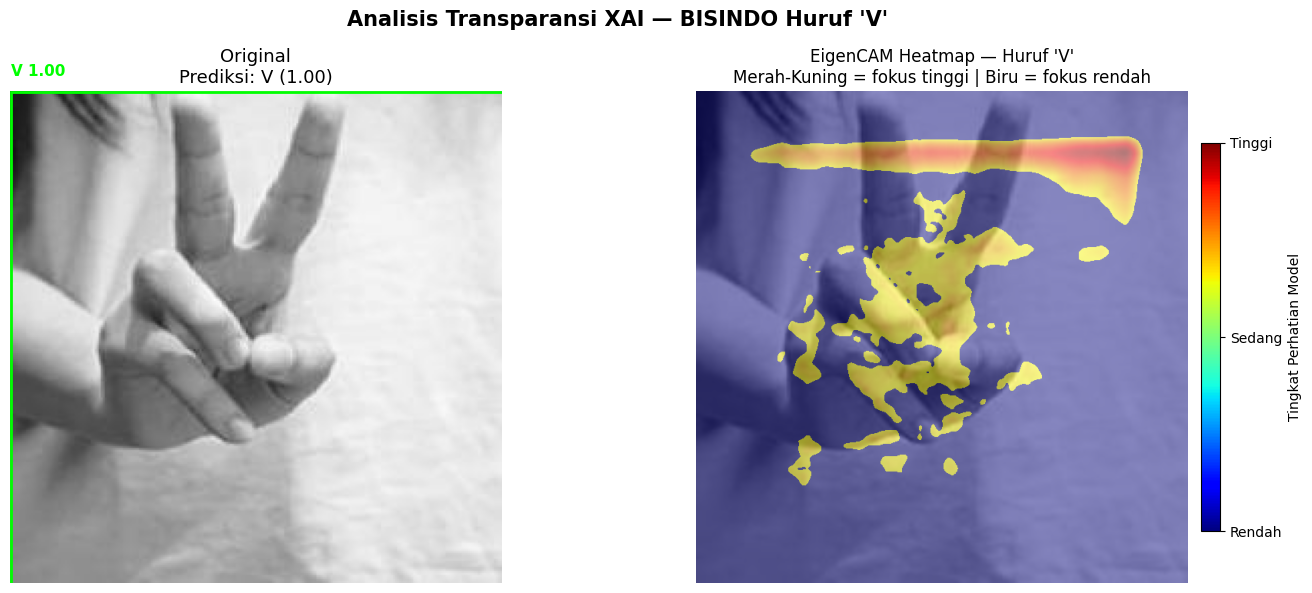

In [ ]:
# =========================================================
# INSTALL & IMPORT
# =========================================================
!pip install -q ultralytics roboflow

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
import os, random
from ultralytics import YOLO

# =========================================================
# LOAD MODEL
# =========================================================
from google.colab import drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

path_best = '/content/drive/MyDrive/Project_BISINDO/Eksperimen_Final/weights/best.pt'
model = YOLO(path_best)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.model.to(device)
model.model.eval()

# =========================================================
# PILIH GAMBAR RANDOM
# =========================================================
test_folder = '/content/BISINDO-Dataset-1/test/images/'
list_foto = [f for f in os.listdir(test_folder) if f.endswith(('.jpg', '.png', '.jpeg'))]
foto_pilihan = random.choice(list_foto)
img_path = os.path.join(test_folder, foto_pilihan)
print(f"Gambar dipilih: {foto_pilihan}")

# =========================================================
# INFERENCE YOLO
# =========================================================
results = model.predict(img_path, conf=0.5, save=False, verbose=False)
result  = results[0]

if len(result.boxes) > 0:
    label = result.names[int(result.boxes.cls[0])]
    conf  = float(result.boxes.conf[0])
    box   = result.boxes.xyxy[0].cpu().numpy().astype(int)
else:
    label, conf = "Tidak Terdeteksi", 0.0
    box = None

print(f"Prediksi: {label} | Confidence: {conf:.2f}")

# =========================================================
# PERSIAPAN GAMBAR
# =========================================================
img_bgr   = cv2.imread(img_path)
img_rgb   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_res   = cv2.resize(img_rgb, (640, 640))
rgb_float = np.float32(img_res) / 255.0

input_tensor = (torch.from_numpy(rgb_float)
                .permute(2, 0, 1)
                .unsqueeze(0)
                .float()
                .to(device))

# =========================================================
# FUNGSI AMBIL AKTIVASI
# =========================================================
def ambil_aktivasi(model, input_tensor, layer_idx):
    activation = {}
    def hook_fn(module, input, output):
        if isinstance(output, tuple):
            activation['feat'] = output[0].detach()
        else:
            activation['feat'] = output.detach()
    hook = model.model.model[layer_idx].register_forward_hook(hook_fn)
    with torch.no_grad():
        _ = model.model(input_tensor)
    hook.remove()
    return activation['feat'].squeeze(0).cpu().numpy()

# =========================================================
# EIGENCAM MULTI-SCALE + GAUSSIAN BLUR + CONTRAST ENHANCEMENT
# =========================================================
def eigencam_multiscale(model, input_tensor, rgb_float, box=None):

    cam_final = np.zeros((640, 640), dtype=np.float32)

    for layer_idx in [16, 19, 22]:
        feat_np = ambil_aktivasi(model, input_tensor, layer_idx)
        C, H, W = feat_np.shape
        feat_flat = feat_np.reshape(C, -1).T

        _, _, Vt = np.linalg.svd(feat_flat, full_matrices=False)

        cam_map = np.zeros((H, W), dtype=np.float32)
        for i in range(min(3, Vt.shape[0])):
            projected = np.einsum('c,chw->hw', Vt[i], feat_np)
            cam_map  += np.abs(projected)

        # Normalisasi per layer
        cam_min, cam_max = cam_map.min(), cam_map.max()
        if cam_max - cam_min > 1e-8:
            cam_map = (cam_map - cam_min) / (cam_max - cam_min)

        # Masking tepi
        border_h = max(1, int(H * 0.10))
        border_w = max(1, int(W * 0.10))
        cam_map[:border_h, :]  = 0
        cam_map[-border_h:, :] = 0
        cam_map[:, :border_w]  = 0
        cam_map[:, -border_w:] = 0

        cam_final += cv2.resize(cam_map, (640, 640))

    # Normalisasi gabungan
    cam_min, cam_max = cam_final.min(), cam_final.max()
    if cam_max - cam_min > 1e-8:
        cam_final = (cam_final - cam_min) / (cam_max - cam_min)

    # Masking bounding box
    if box is not None:
        orig_h, orig_w = img_rgb.shape[:2]
        x1 = int(box[0] * 640 / orig_w)
        y1 = int(box[1] * 640 / orig_h)
        x2 = int(box[2] * 640 / orig_w)
        y2 = int(box[3] * 640 / orig_h)
        pad = 20
        mask = np.zeros((640, 640), dtype=np.float32)
        mask[max(0,y1-pad):min(640,y2+pad),
             max(0,x1-pad):min(640,x2+pad)] = 1.0
        cam_final = cam_final * mask

        cam_min, cam_max = cam_final.min(), cam_final.max()
        if cam_max - cam_min > 1e-8:
            cam_final = (cam_final - cam_min) / (cam_max - cam_min)

    # ✅ GAUSSIAN BLUR — haluskan noise aktivasi di area yang tidak relevan
    # Aktivasi noise (pojok/tepi) biasanya berupa titik kecil terisolasi,
    # blur akan meratakannya sehingga kalah dengan aktivasi tangan yang lebih luas
    cam_final = cv2.GaussianBlur(cam_final, (15, 15), 0)

    # Normalisasi ulang setelah blur
    cam_min, cam_max = cam_final.min(), cam_final.max()
    if cam_max - cam_min > 1e-8:
        cam_final = (cam_final - cam_min) / (cam_max - cam_min)

    # ✅ CONTRAST ENHANCEMENT — naikkan threshold ke 80 agar hanya puncak aktivasi tersisa
    threshold = np.percentile(cam_final[cam_final > 0], 80) if np.any(cam_final > 0) else 0
    cam_final[cam_final < threshold] = 0

    # Normalisasi terakhir setelah thresholding
    cam_min, cam_max = cam_final.min(), cam_final.max()
    if cam_max - cam_min > 1e-8:
        cam_final = (cam_final - cam_min) / (cam_max - cam_min)

    # ✅ Gamma correction — perjelas perbedaan tinggi/rendah
    cam_final = np.power(cam_final, 0.4)

    # Buat overlay
    heatmap_color = cv2.applyColorMap(np.uint8(255 * cam_final), cv2.COLORMAP_JET)
    heatmap_rgb   = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlay = np.clip(0.55 * rgb_float + 0.45 * np.float32(heatmap_rgb) / 255.0, 0, 1)

    return overlay, cam_final

# =========================================================
# JALANKAN
# =========================================================
overlay, cam_map = eigencam_multiscale(model, input_tensor, rgb_float, box=box)

# =========================================================
# TAMPILKAN HASIL
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gambar original + bounding box
axes[0].imshow(img_rgb)
axes[0].set_title(f"Original\nPrediksi: {label} ({conf:.2f})", fontsize=13)
axes[0].axis('off')
if box is not None:
    x1, y1, x2, y2 = box
    rect = plt.Rectangle((x1, y1), x2-x1, y2-y1,
                          linewidth=2, edgecolor='lime', facecolor='none')
    axes[0].add_patch(rect)
    axes[0].text(x1, y1-8, f"{label} {conf:.2f}",
                 color='lime', fontsize=11, fontweight='bold')

# Heatmap
axes[1].imshow(overlay)
axes[1].set_title(
    f"EigenCAM Heatmap — Huruf '{label}'\n"
    f"Merah-Kuning = fokus tinggi | Biru = fokus rendah",
    fontsize=12
)
axes[1].axis('off')

# Colorbar legend
sm = plt.cm.ScalarMappable(cmap='jet', norm=plt.Normalize(0, 1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=axes[1], fraction=0.03, pad=0.02)
cbar.set_label('Tingkat Perhatian Model', fontsize=10)
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(['Rendah', 'Sedang', 'Tinggi'])

plt.suptitle(
    f"Analisis Transparansi XAI — BISINDO Huruf '{label}'",
    fontsize=15, fontweight='bold'
)
plt.tight_layout()
plt.show()

In [ ]:
import os
import shutil
from google.colab import drive

drive.mount('/content/drive')

# Lihat semua file hasil training
hasil_dir = '/content/drive/MyDrive/Project_BISINDO/Eksperimen_Final'
for f in os.listdir(hasil_dir):
    print(f)

Mounted at /content/drive
weights
args.yaml
labels.jpg
train_batch0.jpg
train_batch1.jpg
train_batch2.jpg
train_batch3513.jpg
train_batch3514.jpg
train_batch3515.jpg
results.csv
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch1_pred.jpg
val_batch2_pred.jpg
val_batch2_labels.jpg
BoxPR_curve.png
BoxF1_curve.png
BoxP_curve.png
BoxR_curve.png
confusion_matrix_normalized.png
confusion_matrix.png
results.png
